In [10]:
import xarray as xr
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from Utils import weighted_annual_resample
from nc_processing import calc_spatial_mean

def get_time_slice_mean(ds, timeperiod=['2050', '2069']):
    time_slice = ds.sel(time=slice(timeperiod[0], timeperiod[1]))
    mean_values = time_slice.mean(dim='time')
    return mean_values


from HiLLA_utils import get_ds, cut_incomplete_years, spatial_mean, set_time_to_center_of_bounds, yearly_timeseries

# get standard variable names, settings for plotting, region bounds etc. 
from config import models, regions, HiLLA_altitudes, path_archive, ens_mems_arise_UK, ens_mems_CE, colours, model_colors, model_names, lat_band_dict, UKESM_ARISE_run_IDs, UKESM_ARISE_run_dict, CESM_ARISE_run_IDs


In [28]:
Rho_s = 1769.0 #kgm-3, Mann et al., 2010
modes = ['Nucleation', 'Aitken', 'Accumulation', 'Course']

sigma = {'Nucleation':1.59,
         'Aitken':1.59,
         'Accumulation':1.4,
         'Course':2} # Walters et al. 2019, table 4

avgdro = 6.022E23
molar_mass_air = 0.0289647 # kg/mol
molecules_air_per_kg = avgdro/molar_mass_air

rename_dict = {'h2s04_mmr_nuc':'Nucleation mode (soluble) H2SO4 MMR',
                        'h2so4_mmr_ait':'Aitken mode (soluble) H2SO4 MMR',
                        'h2so4_mmr_acc':'Accumulation mode (soluble) H2SO4 MMR',
                        'h2so4_mmr_cou':'Course mode (soluble) H2SO4 MMR',
                        'nucleation_number':'Nucleation mode (soluble) NUMBER',
                        'aitken_number':'Aitken mode (soluble) NUMBER',
                        'accumulation_number':'Accumulation mode (soluble) NUMBER',
                        'course_number':'Course mode (soluble) NUMBER'}

In [5]:
def add_R_eff(ds):
    """ returns an xarray ds with the spatial and time resolved effective aerosol radius
    calculated as in Visioni 2023 https://acp.copernicus.org/articles/23/663/2023/acp-23-663-2023.html
    (their equations 1-3)
    """
       
    for mode in modes:
        # first get V_i by:
        # V_i = X_i/(Rho_s * N_i)
        # where:
        # X_i is MMR
        # Rho_s = 
        # N_i is number density in number per kg air. We have it as number per molecule air so need to convert
        ds['{} mode volume'.format(mode)] = (1/Rho_s)*ds['{} mode (soluble) H2SO4 MMR'.format(mode)]/(molecules_air_per_kg*ds['{} mode (soluble) NUMBER'.format(mode)])
        
        # second, get R_i by:
        # V_i = 4/3 pi R_i^3 * exp(9/2 * ln2(sigma_i))
        # sigma is the geometric standard deviation of the modes
        # V_i = c * R_i^3
        c = (4/3) * np.pi * np.exp((9/2)*(np.log(sigma[mode])**2))
        ds['{} mode radius'.format(mode)] = np.cbrt((1/c)*ds['{} mode volume'.format(mode)])
    
    a = (ds['Nucleation mode radius']**3)*(molecules_air_per_kg*ds['Nucleation mode (soluble) NUMBER']) + (ds['Aitken mode radius']**3)*(molecules_air_per_kg*ds['Aitken mode (soluble) NUMBER']) + (ds['Accumulation mode radius']**3)*(molecules_air_per_kg*ds['Accumulation mode (soluble) NUMBER']) + (ds['Course mode radius']**3)*(molecules_air_per_kg*ds['Course mode (soluble) NUMBER'])
    b = (ds['Nucleation mode radius']**2)*(molecules_air_per_kg*ds['Nucleation mode (soluble) NUMBER']) + (ds['Aitken mode radius']**2)*(molecules_air_per_kg*ds['Aitken mode (soluble) NUMBER']) + (ds['Accumulation mode radius']**2)*(molecules_air_per_kg*ds['Accumulation mode (soluble) NUMBER']) + (ds['Course mode radius']**2)*(molecules_air_per_kg*ds['Course mode (soluble) NUMBER'])
    ds['R_eff'] = a/b
    return ds
 

In [29]:
mmr_variables = ['h2s04_mmr_nuc', 'h2so4_mmr_ait', 'h2so4_mmr_acc', 'h2so4_mmr_cou']
num_variables = ['nucleation_number', 'aitken_number', 'accumulation_number', 'course_number']

ds_13 = xr.merge([get_ds(run = 'u-dm204dn587', var=var, table='AERmon').mean('longitude').sel(time=slice('2050', '2069')).groupby('time.season').mean('time') for var in mmr_variables+num_variables]).rename(rename_dict)
ds_15 = xr.merge([get_ds(run = 'u-dn760', var=var, table='AERmon').mean('longitude').sel(time=slice('2050', '2069')).groupby('time.season').mean('time') for var in mmr_variables+num_variables]).rename(rename_dict)

In [30]:
ds_13 = add_R_eff(ds_13)
ds_15 = add_R_eff(ds_15)

In [31]:
## also get a backgroun mmr, to act as a threshold for having extra aerosol present
background_dir = '/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/mmrso4/gn/latest/'
ds_background_mmr = xr.open_mfdataset(background_dir+os.listdir(background_dir)[0]).mean('lon')
ds_background_mmr = ds_background_mmr.sel(time=slice('2021', '2051'))
ds_background_mmr =ds_background_mmr.resample(time="Y").mean().load()
ds_background_mmr_std = ds_background_mmr.mmrso4.std('time')
ds_background_mmr_mean = ds_background_mmr.mmrso4.mean('time')


ds_background_mmr_H2SO4_std = (ds_background_mmr_std*(1/0.9796)).rename({'lev':'model_level_number', 'lat':'latitude'})
ds_background_mmr_H2SO4_mean = (ds_background_mmr_mean*(1/0.9796)).rename({'lev':'model_level_number', 'lat':'latitude'})

import scipy.stats as stats
sample_size=(2051-2021)
standard_error = ds_background_mmr_H2SO4_std / np.sqrt(sample_size)
# Find the critical t-value for 95% confidence (two-tailed)
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha / 2, df=sample_size - 1)
# Calculate the threshold anomaly that would exceed the threshold
threshold_anom = t_critical * standard_error

<string>:6: FutureWarning: 'Y' is deprecated and will be removed in a future version. Please use 'YE' instead of 'Y'.


In [33]:
ds_HiLLA = {'13km':ds_13, '15km':ds_15}

In [49]:
import matplotlib
matplotlib.rcParams.update({'font.size': 15})

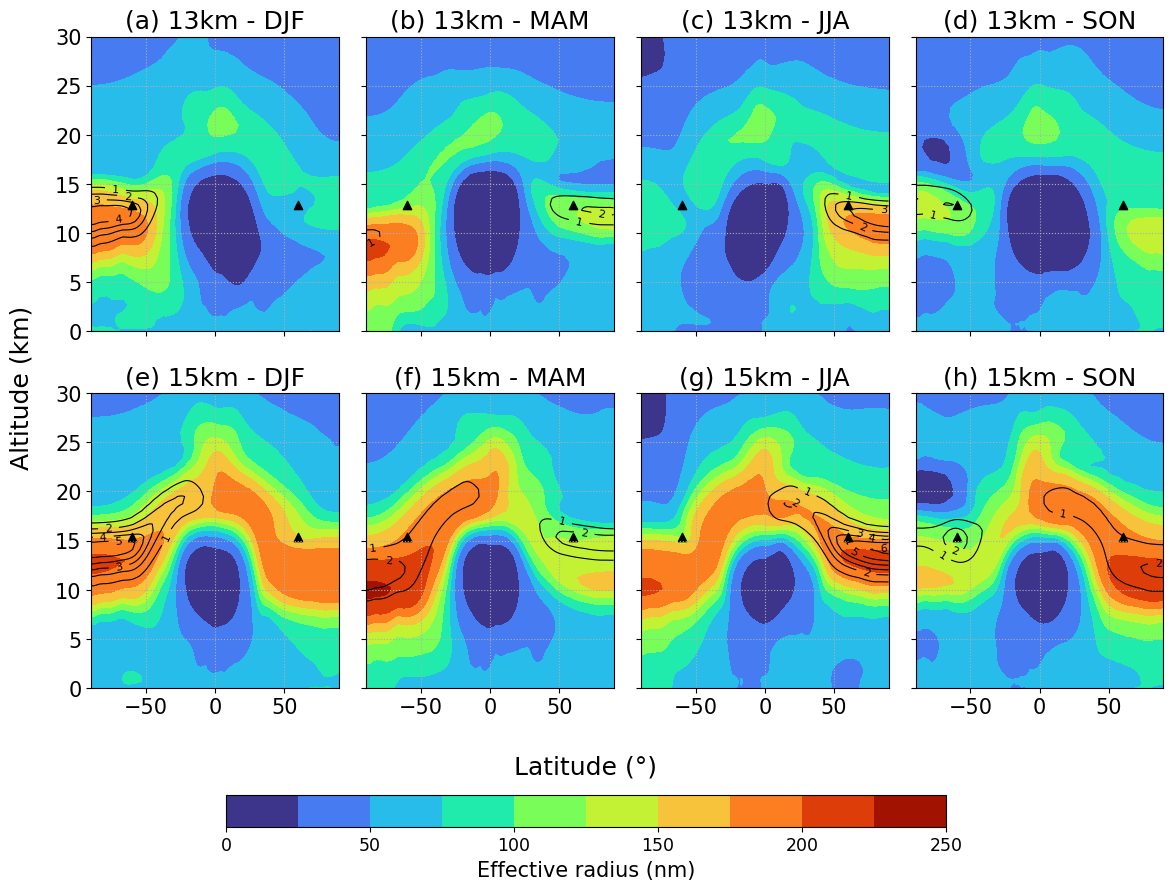

In [51]:

fig, axs = plt.subplots(2, 4, figsize=(12, 8),
                        sharex='all', sharey='all')
i=0
labs = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']
for alt in ['13km', '15km']:
    for season in ['DJF', 'MAM', 'JJA', 'SON']:
        ax = axs.flatten()[i]
        ds = ds_HiLLA[alt]
        ds = ds.sel(season=season)

        ds['total_mmr'] = ds['Nucleation mode (soluble) H2SO4 MMR'] + ds['Aitken mode (soluble) H2SO4 MMR'] + ds['Accumulation mode (soluble) H2SO4 MMR'] + ds['Course mode (soluble) H2SO4 MMR']
        
        """
        ds['total_mmr_anom'] = ds['total_mmr']
        ds['total_mmr_anom'].values = ds['total_mmr'].values - ds_background_mmr_H2SO4_mean.values
        ds['total_mmr_threshold_anom'] = ds['total_mmr']
        ds['total_mmr_threshold_anom'].values = threshold_anom.values
        masked_ds = ds.where(ds['total_mmr_anom'] > ds['total_mmr_threshold_anom'])
        """
        cs=ax.contourf(ds.latitude.values, 
                       0.001*ds.altitude.values, 
                       1E9*ds['R_eff'].values,
                       levels = np.arange(0, 275, 25),
                       cmap='turbo',
                       )
        
        # also contour the total mmr:

        cs2 = ax.contour(ds.latitude.values, 
                         0.001*ds.altitude.values, 
                         ds['total_mmr'].values,
                         levels = np.arange(0, 8E-8, 1E-8),
                         colors='black',
                         linewidths=0.8)
        
        # label the contours
        ax.clabel(cs2, colors='black', fontsize=8)

        ax.set_ylim(0, 30)
        if alt == '13km':
            ax.scatter([60, -60], [12.9, 12.9], marker='^', color='black')
        elif alt == '15km':
            ax.scatter([60, -60], [15.4, 15.4], marker='^', color='black')
        ax.grid(ls='dotted')
        ax.set_title('{} {} - {}'.format(labs[i], alt, season))
        i=i+1
    
fig.supxlabel('Latitude (°)')
fig.supylabel('Altitude (km)' )

plt.tight_layout()

cbar_ax1 = fig.add_axes([0.2, -0.05, 0.6, 0.04])
cbar1 = fig.colorbar(cs, cax=cbar_ax1, orientation='horizontal', label='Effective radius (nm)')
cbar1.ax.tick_params(labelsize='small')

plt.savefig('Figures/R_eff_zonal_height_sigmask_UKESM.jpg', dpi=450, bbox_inches='tight')
plt.show()